<a href="https://colab.research.google.com/github/IvanBaroni/projects-in-data/blob/main/IGN_Games_Exploratory_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**QUESTIONS**

1. What is the average score by **Platform**?

2. What is the average score by **Manufacturer**?

3. What is the average score by **Genre**?

4. What are the main differences between games that are **editors choice**?

5. What game **genres** are getting more popular with time?

6. How long has each **platform** had games released?

7. What **time of the year** do we have more game launches?

8. What are the 3 best games by **Platform**?

9. What is the best game for each **Genre**?

10. Which **manufacturer** has more consistency when it comes to score?


# Importing the Dataset

In [1]:
#Libraries
import pandas as pd
import numpy as np

import io
import requests

import matplotlib.pyplot as plt
import seaborn as sns

!pip install ydata-profiling > /dev/null


In [2]:
#Import Dataset

url = "https://raw.githubusercontent.com/TheSarang/IGN-20-years-of-Games-Analysis/master/ign.csv"
response = requests.get(url)
df = pd.read_csv(io.StringIO(response.text))

df.head()

,Unnamed: 0,score_phrase,title,url,platform,score,genre,editors_choice,release_year,release_month,release_day
0,0,Amazing,LittleBigPlanet PS Vita,/games/littlebigplanet-vita/vita-98907,PlayStation Vita,9.0,Platformer,Y,2012,9,12
1,1,Amazing,LittleBigPlanet PS Vita -- Marvel Super Hero E...,/games/littlebigplanet-ps-vita-marvel-super-he...,PlayStation Vita,9.0,Platformer,Y,2012,9,12
2,2,Great,Splice: Tree of Life,/games/splice/ipad-141070,iPad,8.5,Puzzle,N,2012,9,12
3,3,Great,NHL 13,/games/nhl-13/xbox-360-128182,Xbox 360,8.5,Sports,N,2012,9,11
4,4,Great,NHL 13,/games/nhl-13/ps3-128181,PlayStation 3,8.5,Sports,N,2012,9,11


In [3]:
df_summary = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Unique Count': df.nunique(),
    'Type': df.dtypes
    })

df_summary

,Null Count,Unique Count,Type
Unnamed: 0,0,18625,int64
score_phrase,0,11,object
title,0,12589,object
url,0,18577,object
platform,0,59,object
score,0,93,float64
genre,36,112,object
editors_choice,0,2,object
release_year,0,22,int64
release_month,0,12,int64


In [4]:
# correct a faulty register

# Rename the "Unnamed: 0" column to "id"
df = df.rename(columns={'Unnamed: 0': 'id'})

# Change the release date for the row with id == 516
df.loc[df['id'] == 516, ['release_year', 'release_month', 'release_day']] = [2012, 4, 24]

# Display the updated row to confirm the change
display(df[df['id'] == 516])

,id,score_phrase,title,url,platform,score,genre,editors_choice,release_year,release_month,release_day
516,516,Great,The Walking Dead: The Game -- Episode 1: A New...,/games/the-walking-dead-season-1-episode-1/xbo...,Xbox 360,8.5,Adventure,N,2012,4,24


In [5]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Profiling Report")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:02<00:00,  5.48it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# 1. What is the average score by **Platform**?

In [6]:
avg_score_by_platform = df.groupby('platform')['score'].mean().round(3).reset_index()
platform_counts = df['platform'].value_counts().reset_index()

platform_counts.columns = ['platform', 'count']

platform_analysis = pd.merge(avg_score_by_platform, platform_counts, on='platform')
platform_analysis

,platform,score,count
0,Android,7.546,39
1,Arcade,6.036,11
2,Atari 2600,5.900,5
3,Atari 5200,8.000,2
4,Commodore 64/128,6.417,6
5,DVD / HD Video Game,1.000,1
6,Dreamcast,7.370,286
7,Dreamcast VMU,3.000,1
8,Game Boy,7.814,22
9,Game Boy Advance,6.627,623


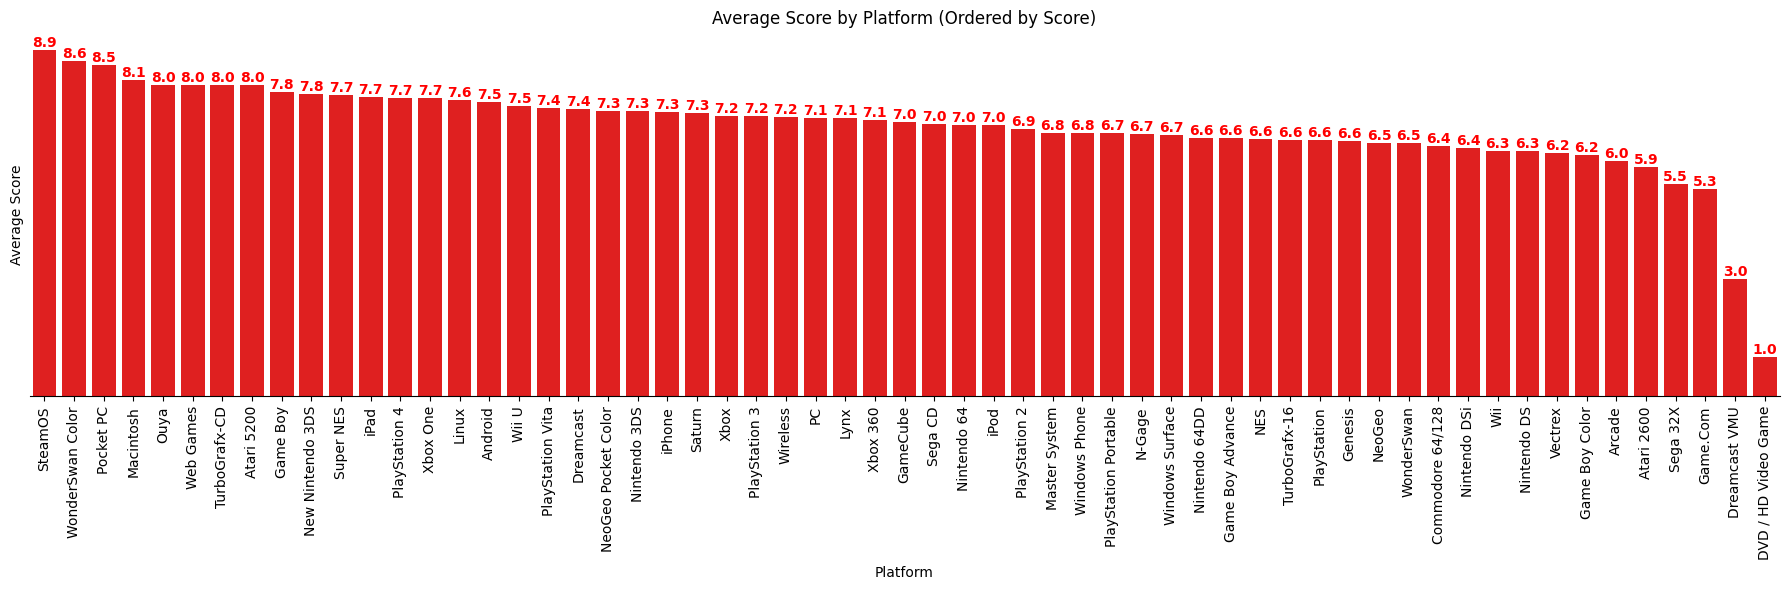

In [7]:
# Order by score
platform_analysis_sorted = platform_analysis.sort_values(by='score', ascending=False)

# Plotting
plt.figure(figsize=(18, 6))
ax = sns.barplot(x='platform', y='score', data=platform_analysis_sorted, color='red')
plt.xticks(rotation=90)
plt.title('Average Score by Platform (Ordered by Score)')
plt.xlabel('Platform')
plt.ylabel('Average Score')

# Add score numbers on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='edge', color='red',  weight='bold')

# Visual details
ax.set_yticks([]) # Hide y-axis labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

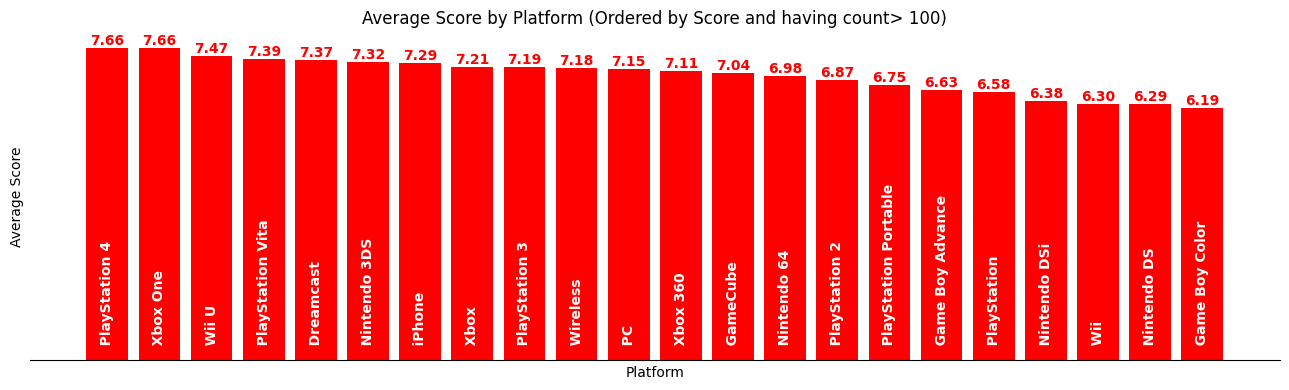

In [8]:
# Filter by count
platform_analysis_filtered = platform_analysis[platform_analysis['count'] > 100]
platform_analysis_filtered

# Order by score
platform_analysis_sorted = platform_analysis_filtered.sort_values(by='score', ascending=False)

# Plotting with matplotlib only
plt.figure(figsize=(13, 4))
ax = plt.bar(platform_analysis_sorted['platform'], platform_analysis_sorted['score'], color='red')

plt.title('Average Score by Platform (Ordered by Score and having count> 100)')
plt.xlabel('Platform')
plt.ylabel('Average Score')
plt.xticks(rotation=90)

# Add score numbers on top of bars and platform names inside bars at the base
for i, (platform, score) in enumerate(zip(platform_analysis_sorted['platform'], platform_analysis_sorted['score'])):
    # Add score numbers on top of bars
    plt.text(i, score, f'{score:.2f}', ha='center', va='bottom', color='red', weight='bold')
    # Add platform names inside bars at the base
    plt.text(i, 0, "   "+platform, ha='center', va='bottom', color='white',  weight='bold', rotation=90, fontsize=10)

# Visual details
ax = plt.gca() # Get the current axes
ax.set_yticks([]) # Hide y-axis labels
ax.set_xticks([]) # Hide y-axis labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

# 2. What is the average score by **Manufacturer**?

In [9]:
sheet_url = "https://docs.google.com/spreadsheets/d/1O-7U1alPypICeYWkjbs0HwPODcqYaI2dS7IlJJNZyW8/edit?usp=sharing"
sheet_url = sheet_url.replace('/edit?usp=sharing', '/export?format=csv')

df_manufacturer = pd.read_csv(sheet_url)

# Merge the original dataframe with the manufacturer dataframe
df = pd.merge(df, df_manufacturer, left_on='platform', right_on='platform', how='left')

print(df[['platform', 'manufacturer']].head())

           platform manufacturer
0  PlayStation Vita         Sony
1  PlayStation Vita         Sony
2              iPad        Apple
3          Xbox 360    Microsoft
4     PlayStation 3         Sony


In [10]:
avg_score_by_manufacturer = df.groupby('manufacturer')['score'].mean().round(3).reset_index()
manufacturer_counts = df['manufacturer'].value_counts().reset_index()

manufacturer_counts.columns = ['manufacturer', 'count']

manufacturer_analysis = pd.merge(avg_score_by_manufacturer, manufacturer_counts, on='manufacturer')
manufacturer_analysis

,manufacturer,score,count
0,Apple,7.384,1039
1,Atari,7.084,89
2,Bandai,6.920,5
3,Google,7.546,39
4,Microsoft,7.177,2676
5,NEC,6.684,43
6,Nintendo,6.548,4907
7,Nokia,6.730,30
8,Other,7.148,4315
9,SNK,7.122,41


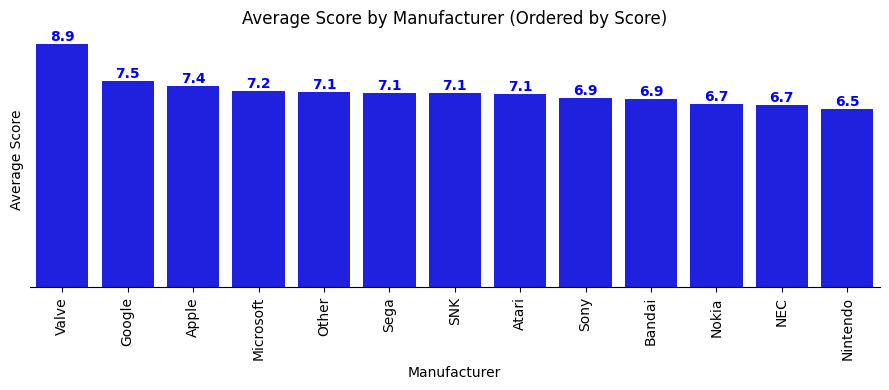

In [11]:
# Order by score
manufacturer_analysis_sorted = manufacturer_analysis.sort_values(by='score', ascending=False)

# Plotting
plt.figure(figsize=(9, 4))
ax = sns.barplot(x='manufacturer', y='score', data=manufacturer_analysis_sorted, color='blue')
plt.xticks(rotation=90)
plt.title('Average Score by Manufacturer (Ordered by Score)')
plt.xlabel('Manufacturer')
plt.ylabel('Average Score')

# Add score numbers on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='edge', color='blue',  weight='bold')

# Visual details
ax.set_yticks([]) # Hide y-axis labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

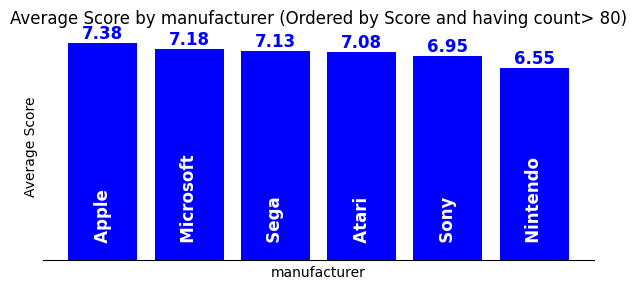

In [12]:
# Filter by count
manufacturer_analysis_filtered = manufacturer_analysis[manufacturer_analysis['count'] > 80]
manufacturer_analysis_filtered = manufacturer_analysis_filtered[manufacturer_analysis_filtered['manufacturer'] != 'Other']
manufacturer_analysis_filtered

# Order by score
manufacturer_analysis_sorted = manufacturer_analysis_filtered.sort_values(by='score', ascending=False)

# Plotting with matplotlib only
plt.figure(figsize=(6, 3))
ax = plt.bar(manufacturer_analysis_sorted['manufacturer'], manufacturer_analysis_sorted['score'], color='blue')

plt.title('Average Score by manufacturer (Ordered by Score and having count> 80)')
plt.xlabel('manufacturer')
plt.ylabel('Average Score')
plt.xticks(rotation=90)

# Add score numbers on top of bars and manufacturer names inside bars at the base
for i, (manufacturer, score) in enumerate(zip(manufacturer_analysis_sorted['manufacturer'], manufacturer_analysis_sorted['score'])):
    # Add score numbers on top of bars
    plt.text(i, score, f'{score:.2f}', ha='center', va='bottom', color='blue', weight='bold', fontsize=12)
    # Add manufacturer names inside bars at the base
    plt.text(i, 0, "   "+manufacturer, ha='center', va='bottom', color='white',  weight='bold', rotation=90, fontsize=12)

# Visual details
ax = plt.gca() # Get the current axes
ax.set_yticks([]) # Hide y-axis labels
ax.set_xticks([]) # Hide y-axis labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

# 3. What is the average score by **Genre**?

In [13]:
# Delete spaces from column genre
df['genre'] = df['genre'].str.replace(' ', '')

# create dummy variables for the 'genre' column, handling null values and splitting by comma
genre_dummies = df['genre'].str.get_dummies(sep=',')

# join the dummy variables to the original dataframe
df = df.join(genre_dummies)

In [14]:
pd.set_option('display.max_columns', None)
df.head()

,id,score_phrase,title,url,platform,score,genre,editors_choice,release_year,release_month,release_day,manufacturer,Action,Adult,Adventure,Baseball,Battle,Board,Card,Casino,Compilation,Editor,Educational,Episodic,Fighting,First-Person,Flight,Golf,Hardware,Hunting,Music,Other,Party,Pinball,Platformer,Productivity,Puzzle,RPG,Racing,Shooter,Simulation,Sports,Strategy,Trivia,VirtualPet,WordGame,Wrestling
0,0,Amazing,LittleBigPlanet PS Vita,/games/littlebigplanet-vita/vita-98907,PlayStation Vita,9.0,Platformer,Y,2012,9,12,Sony,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,1,Amazing,LittleBigPlanet PS Vita -- Marvel Super Hero E...,/games/littlebigplanet-ps-vita-marvel-super-he...,PlayStation Vita,9.0,Platformer,Y,2012,9,12,Sony,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,2,Great,Splice: Tree of Life,/games/splice/ipad-141070,iPad,8.5,Puzzle,N,2012,9,12,Apple,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,3,Great,NHL 13,/games/nhl-13/xbox-360-128182,Xbox 360,8.5,Sports,N,2012,9,11,Microsoft,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,4,Great,NHL 13,/games/nhl-13/ps3-128181,PlayStation 3,8.5,Sports,N,2012,9,11,Sony,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [15]:
# Calculating score average by genre

# Select only the genre dummy columns and the 'score' column
genre_columns = genre_dummies.columns

# Calculate the sum of scores for each genre by multiplying the dummy genre columns by the 'score' column
score_sum_by_genre = df[genre_columns].multiply(df['score'], axis=0).sum(axis=0)

# Calculate the count of games in each genre
genre_counts = df[genre_columns].sum(axis=0)

# Calculate the average score for each genre by dividing the sum of scores by the count
average_scores = score_sum_by_genre / genre_counts



In [16]:
# Convert the average_scores Series to a DataFrame
average_scores_df = average_scores.reset_index()
average_scores_df.columns = ['genre', 'average_score']

# Convert the genre_counts Series to a DataFrame
genre_counts_df = genre_counts.reset_index()
genre_counts_df.columns = ['genre', 'count']

# Merge the two DataFrames on the 'genre' column
genre_analysis = pd.merge(average_scores_df, genre_counts_df, on='genre')

# Display the combined DataFrame
display(genre_analysis.round(2))

,genre,average_score,count
0,Action,6.82,5894
1,Adult,5.40,3
2,Adventure,7.08,2032
3,Baseball,6.95,4
4,Battle,6.81,86
5,Board,6.61,123
6,Card,6.89,177
7,Casino,5.13,31
8,Compilation,6.98,215
9,Editor,7.35,13


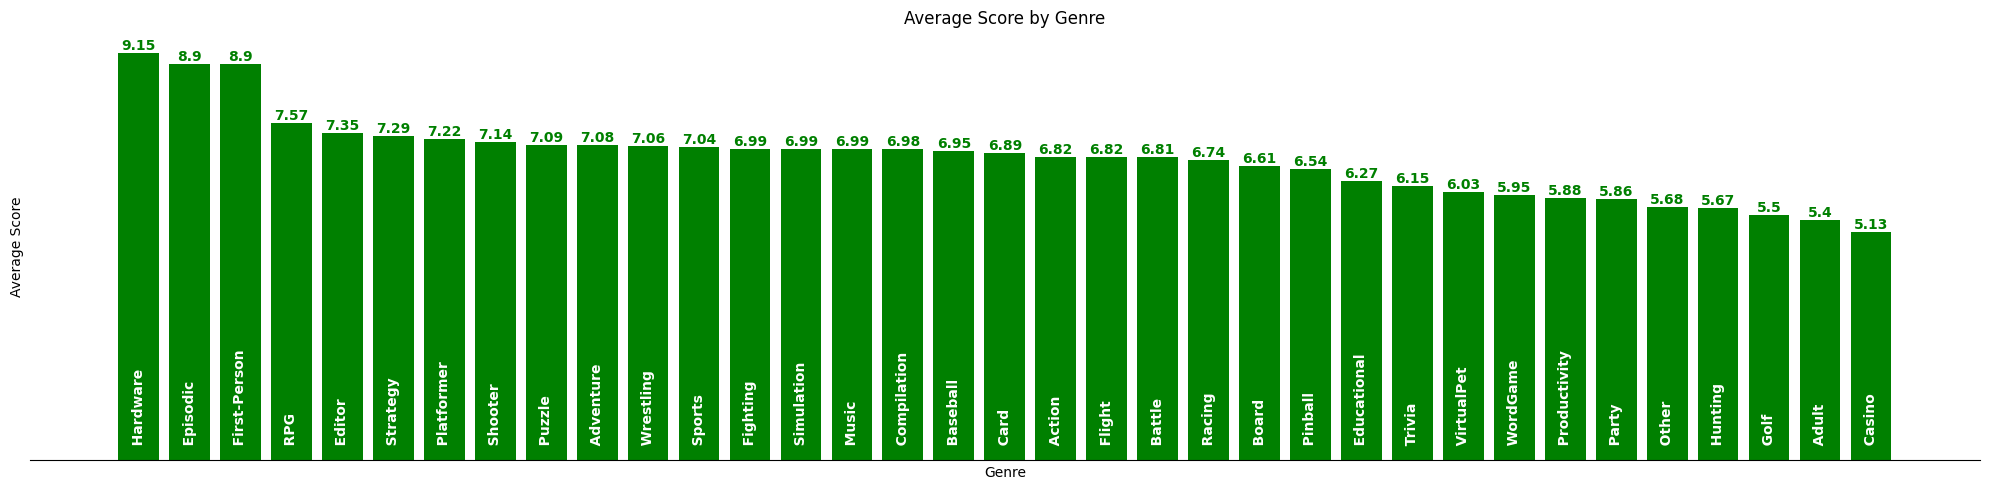

In [17]:
sorted_average_scores = average_scores.sort_values(ascending=False).round(2)

fig, ax = plt.subplots(figsize=(20, 5)) # Create figure and axes
bars = ax.bar(sorted_average_scores.index, sorted_average_scores.values, color='green')
ax.set_xlabel('Genre')
ax.set_ylabel('Average Score')
ax.set_title('Average Score by Genre')

ax.set_xticks([]) # Hide x-axis labels
ax.set_yticks([]) # Hide y-axis labels
ax.spines['top'].set_visible(False) # Hide the top spine
ax.spines['right'].set_visible(False) # Hide the right spine
ax.spines['left'].set_visible(False) # Hide the left spine


# Add numbers on top of the bars and rotated genre names inside the bars
for bar in bars:
    yval = bar.get_height()
    xval = bar.get_x()
    width = bar.get_width()
    genre_name = sorted_average_scores.index[list(bars).index(bar)]
    # Add number on top
    ax.text(xval + width/2., yval, round(yval, 2), ha='center', va='bottom', color='green', weight='bold')
    # Add rotated genre name inside, starting from the base and in bold
    ax.text(xval + width/2., 0, "   "+genre_name, ha='center', va='bottom', rotation=90, color='white', weight='bold')
plt.tight_layout()
plt.show()

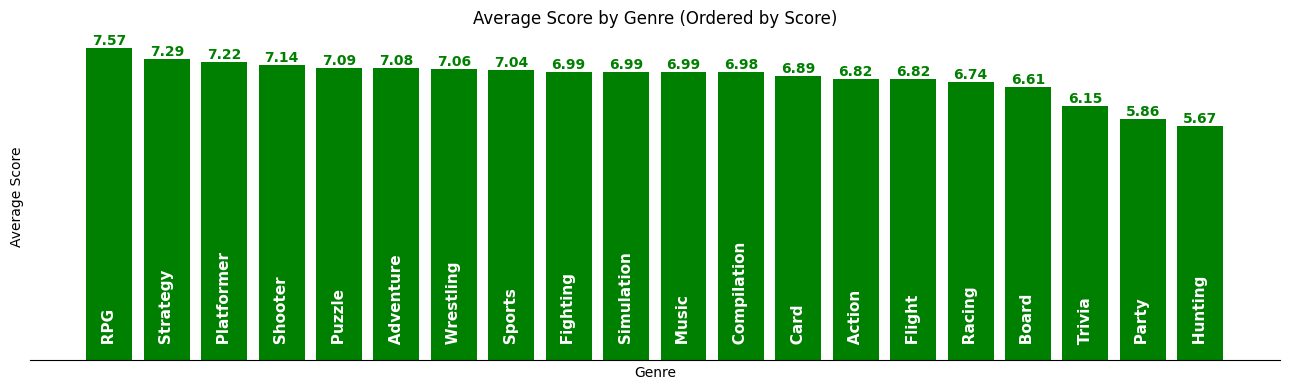

In [18]:
genre_analysis_filtered = genre_analysis[genre_analysis['count'] > 100]
genre_analysis_filtered

# Order by score
genre_analysis_sorted = genre_analysis_filtered.sort_values(by='average_score', ascending=False)

# Plotting with matplotlib only
plt.figure(figsize=(13, 4))
ax = plt.bar(genre_analysis_sorted['genre'], genre_analysis_sorted['average_score'], color='green')

plt.title('Average Score by Genre (Ordered by Score)')
plt.xlabel('Genre')
plt.ylabel('Average Score')
plt.xticks(rotation=90)

# Add average_score numbers on top of bars and genre names inside bars at the base
for i, (genre, average_score) in enumerate(zip(genre_analysis_sorted['genre'], genre_analysis_sorted['average_score'])):
    # Add average_score numbers on top of bars
    plt.text(i, average_score, f'{average_score:.2f}', ha='center', va='bottom', color='green', weight='bold')
    # Add genre names inside bars at the base
    plt.text(i, 0, "   "+genre, ha='center', va='bottom', color='white',  weight='bold', rotation=90, fontsize=11)

# Make the square around the chart invisible
ax = plt.gca() # Get the current axes
ax.set_yticks([]) # Hide y-axis labels
ax.set_xticks([]) # Hide y-axis labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)


plt.tight_layout()
plt.show()


# 4. What are the main differences between games that are **editors choice**?

In [19]:
# Group by 'editors_choice' and calculate the average score
avg_score_by_editors_choice = df.groupby('editors_choice')['score'].mean().reset_index().round(2)

# Display the result
avg_score_by_editors_choice

,editors_choice,score
0,N,6.50
1,Y,8.87


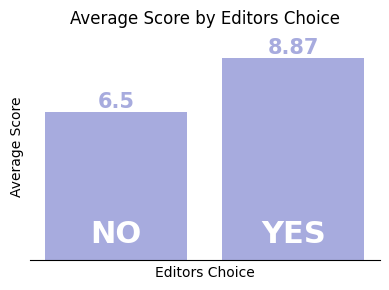

In [20]:
# Create a bar chart for average score by editors choice
plt.figure(figsize=(4, 3)) # Adjusted figure height slightly to better accommodate labels inside
ax = plt.bar(avg_score_by_editors_choice['editors_choice'], avg_score_by_editors_choice['score'], color='#A7ABDE') # Use light purple color

plt.title('Average Score by Editors Choice')
plt.xlabel('Editors Choice')
plt.ylabel('Average Score')
plt.ylim(0, 10) # Set y-axis limit to match score range

# Add average score values on top of the bars and labels inside the bars
for i, bar in enumerate(ax):
    yval = bar.get_height()
    xval = bar.get_x()
    width = bar.get_width()
    # Add average score on top
    plt.text(xval + width/2, yval, round(yval, 2), ha='center', va='bottom', color='#A7ABDE', weight='bold', fontsize=15)

    # Add label inside the bar
    label = avg_score_by_editors_choice['editors_choice'].iloc[i]
    display_label = 'NO' if label == 'N' else 'YES'
    plt.text(xval + width/2, 0.5, display_label, ha='center', va='bottom', color='white', weight='bold', fontsize=22) # Position label near the bottom

# Make the square around the chart invisible
ax = plt.gca() # Get the current axes
ax.set_yticks([]) # Hide y-axis labels
ax.set_xticks([]) # Hide y-axis labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)


plt.tight_layout()
plt.show()

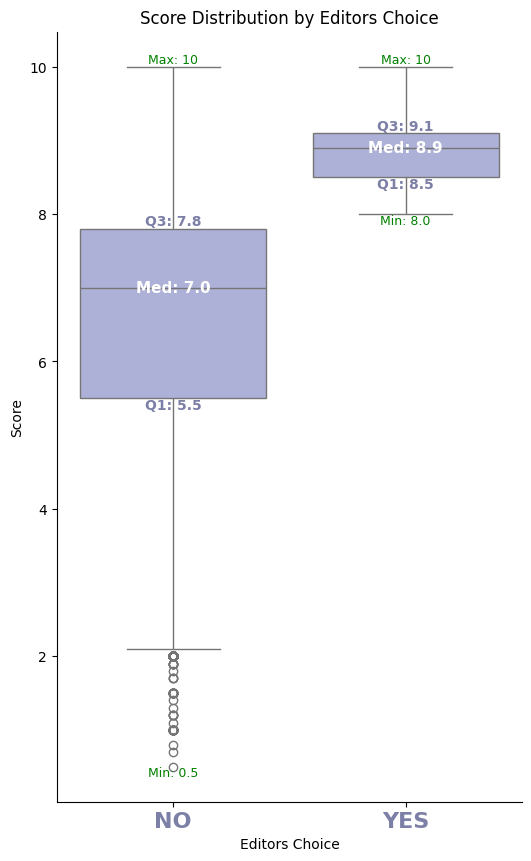

In [21]:
# Generate a boxplot for 'editors_choice' using 'score'
plt.figure(figsize=(6, 10)) # Increased figure height to better accommodate min/max labels
# Set the order of the boxes to 'N' then 'Y'
ax = sns.boxplot(x='editors_choice', y='score', data=df, color='#A7ABDE', order=['N', 'Y'])
plt.title('Score Distribution by Editors Choice')
plt.xlabel('Editors Choice')
plt.ylabel('Score')
# Set the x-axis labels to match the new order
plt.xticks([0, 1], ['NO', 'YES'], size='16', color='#7c7fa6', weight='bold' )

# Make the square around the chart invisible
ax = plt.gca() # Get the current axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Calculate quartiles, average, min, and max for each editors_choice group
quartiles_and_stats = df.groupby('editors_choice')['score'].agg(['min', 'max', 'median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75), 'mean']).reset_index()
quartiles_and_stats.columns = ['editors_choice', 'min', 'max', 'median', 'q1', 'q3', 'mean']


# Add quartile, median, min, and max values to the boxplot
# Iterate in the order of the boxplot ('N' then 'Y')
for i, choice in enumerate(['N', 'Y']):
    row = quartiles_and_stats[quartiles_and_stats['editors_choice'] == choice].iloc[0]
    min_score = row['min']
    max_score = row['max']
    median_score = row['median']
    q1_score = row['q1']
    q3_score = row['q3']

    # Add median
    ax.text(i, median_score, f'Med: {median_score:.1f}', ha='center', va='center', color='white', fontsize=11, weight='bold')

    # Add Q1 (positioned at q1_score)
    ax.text(i, q1_score, f'Q1: {q1_score:.1f}', ha='center', va='top', color='#7c7fa6', fontsize=10, weight='bold')

    # Add Q3 (positioned at q3_score)
    ax.text(i, q3_score, f'Q3: {q3_score:.1f}', ha='center', va='bottom', color='#7c7fa6', fontsize=10, weight='bold')

    # Add Min (positioned below the lower whisker)
    ax.text(i, min_score, f'Min: {min_score:.1f}', ha='center', va='top', color='green', fontsize=9)

    # Add Max (positioned above the upper whisker)
    ax.text(i, max_score, f'Max: {max_score:.0f}', ha='center', va='bottom', color='green', fontsize=9)


plt.show()

In [22]:
# Group by score_phrase and calculate the average score and count
score_phrase_analysis = df.groupby('score_phrase')['score'].agg(['mean', 'count']).reset_index()

# Rename the columns for clarity
score_phrase_analysis.columns = ['score_phrase', 'average_score', 'count']

# Order the table by average score in descending order
score_phrase_analysis = score_phrase_analysis.sort_values(by='average_score', ascending=False)

# Format the 'average_score' column to 2 decimal places
score_phrase_analysis['average_score'] = score_phrase_analysis['average_score'].round(2)

# Display the table
display(score_phrase_analysis)

,score_phrase,average_score,count
6,Masterpiece,10.00,55
0,Amazing,9.18,1804
5,Great,8.32,4773
4,Good,7.37,4741
8,Okay,6.37,2945
7,Mediocre,5.32,1959
2,Bad,4.33,1269
1,Awful,3.29,664
9,Painful,2.27,340
10,Unbearable,1.29,72


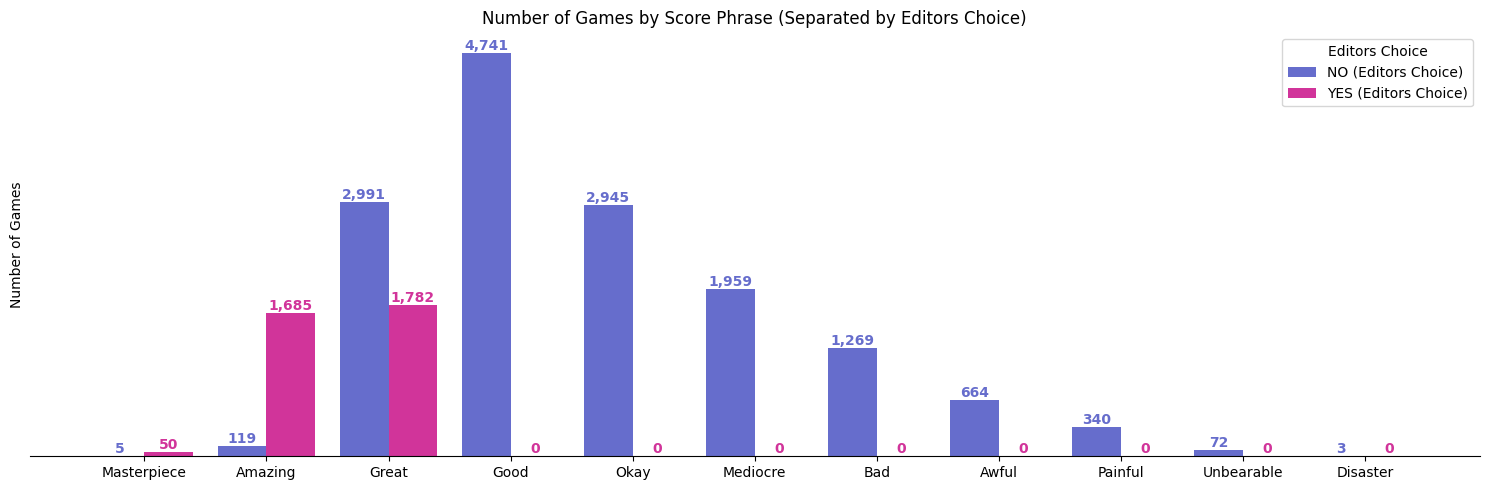

In [23]:
score_phrase_by_editors_choice = df.groupby(['editors_choice', 'score_phrase']).size().unstack(fill_value=0)


# Define the desired order of score phrases (reusing from cell CVBUZvSrr8l5)
score_phrase_order = ['Masterpiece', 'Amazing', 'Great', 'Good', 'Okay', 'Mediocre', 'Bad', 'Awful', 'Painful', 'Unbearable', 'Disaster']

# Filter the score_phrase_by_editors_choice DataFrame for 'editors_choice' = 'N' and 'Y'
score_phrase_counts_N = score_phrase_by_editors_choice.loc['N']
score_phrase_counts_Y = score_phrase_by_editors_choice.loc['Y']

# Convert the filtered Series to DataFrames and rename columns
score_phrase_counts_N_df = score_phrase_counts_N.reset_index()
score_phrase_counts_N_df.columns = ['score_phrase', 'count']
score_phrase_counts_Y_df = score_phrase_counts_Y.reset_index()
score_phrase_counts_Y_df.columns = ['score_phrase', 'count']

# Reindex the DataFrames to match the desired order
score_phrase_counts_N_ordered = score_phrase_counts_N_df.set_index('score_phrase').reindex(score_phrase_order).reset_index()
score_phrase_counts_Y_ordered = score_phrase_counts_Y_df.set_index('score_phrase').reindex(score_phrase_order).reset_index()

# Create a figure and axes
plt.figure(figsize=(15, 5)) # Increased figure width for side-by-side bars
ax = plt.gca()

bar_width = 0.40 # Width of each bar
x_positions = np.arange(len(score_phrase_order)) # Base x-positions for each score phrase

# Plot the bar chart for 'N' (shifted to the left) and store the bar objects
bars_N = ax.bar(x_positions - bar_width/2, score_phrase_counts_N_ordered['count'], bar_width, color='#666dcc', label='NO (Editors Choice)')

# Plot the bar chart for 'Y' (shifted to the right) and store the bar objects
bars_Y = ax.bar(x_positions + bar_width/2, score_phrase_counts_Y_ordered['count'], bar_width, color='#d1349a', label='YES (Editors Choice)')


plt.title('Number of Games by Score Phrase (Separated by Editors Choice)')
#plt.xlabel('Score Phrase')
plt.ylabel('Number of Games')
plt.xticks(x_positions, score_phrase_order, rotation=0, ha='center') # Set x-ticks at the center of the grouped bars
plt.legend(title='Editors Choice')

# Add count numbers on top of the 'N' bars with comma formatting
for bar in bars_N:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval):,}', ha='center', va='bottom', weight='bold', color='#666dcc') # Use f-string with comma

# Add count numbers on top of the 'Y' bars with comma formatting
for bar in bars_Y:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval):,}', ha='center', va='bottom', weight='bold', color='#d1349a') # Use f-string with comma


# Make the square around the chart invisible
ax = plt.gca() # Get the current axes
ax.set_yticks([]) # Hide y-axis labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)


plt.tight_layout()
plt.show()

# 5. What game **genres** are getting more popular with time?

In [24]:
# Create a new column called "release_date"
# Temporarily rename columns for pd.to_datetime
temp_df = df[['release_year', 'release_month', 'release_day']].copy()
temp_df.columns = ['year', 'month', 'day']
df['release_date'] = pd.to_datetime(temp_df)

# Group by release_date and count the number of games
games_by_date = df.groupby('release_date').size().reset_index(name='game_count')

In [25]:
# Order the DataFrame by release_date
df_ordered_by_date = df.sort_values(by='release_date')

# Display the ordered DataFrame
display(df_ordered_by_date.head()) # Displaying head for brevity

,id,score_phrase,title,url,platform,score,genre,editors_choice,release_year,release_month,release_day,manufacturer,Action,Adult,Adventure,Baseball,Battle,Board,Card,Casino,Compilation,Editor,Educational,Episodic,Fighting,First-Person,Flight,Golf,Hardware,Hunting,Music,Other,Party,Pinball,Platformer,Productivity,Puzzle,RPG,Racing,Shooter,Simulation,Sports,Strategy,Trivia,VirtualPet,WordGame,Wrestling,release_date
515,515,Good,Baku Baku,/games/baku-baku/saturn-194,Saturn,7.0,Puzzle,N,1996,6,18,Sega,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1996-06-18
514,514,Amazing,Super Mario 64,/games/super-mario-64/n64-606,Nintendo 64,9.8,Platformer,Y,1996,9,25,Nintendo,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1996-09-25
488,488,Great,Pilotwings 64,/games/pilotwings-64/n64-83,Nintendo 64,8.2,Flight,N,1996,9,25,Nintendo,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1996-09-25
487,487,Mediocre,Batman Forever: The Arcade Game,/games/batman-forever/ps-318,PlayStation,5.0,Action,N,1996,11,2,Sony,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1996-11-02
486,486,Bad,Cruis'n USA,/games/cruisn-usa/n64-498,Nintendo 64,4.0,Racing,N,1996,11,14,Nintendo,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1996-11-14


In [26]:
import plotly.express as px

# Create an interactive trendline chart with Plotly Express
fig = px.line(games_by_date, x='release_date', y='game_count',
              title='Number of Games Released per Day (Interactive)')

# Display the interactive plot
fig.show()

## Patform Evolution

In [35]:
import plotly.express as px

# Group by platform and then resample the release_date to monthly frequency, summing the game counts
# Use 'on' parameter to specify the datetime column for resampling
games_by_month_platform = df.groupby('platform').resample('ME', on='release_date').size().reset_index(name='game_count')

# Get platforms with a total count greater than 100 (reusing platform_analysis)
platforms_to_keep = platform_analysis[platform_analysis['count'] > 100]['platform'].tolist()

# Filter the monthly game counts to include only the platforms to keep
games_by_month_platform_filtered = games_by_month_platform[games_by_month_platform['platform'].isin(platforms_to_keep)]


# Create an interactive trendline chart broken down by platform, using filtered monthly counts
fig = px.line(games_by_month_platform_filtered, x='release_date', y='game_count', color='platform',
              title='Number of Games Released per Month by Platform (Interactive, Count > 100)')

# Display the interactive plot
fig.show()

In [36]:
import plotly.express as px

# Group by platform and then resample the release_date to yearly frequency, summing the game counts
# Use 'on' parameter to specify the datetime column for resampling
games_by_year_platform = df.groupby('platform').resample('YE', on='release_date').size().reset_index(name='game_count')

# Get platforms with a total count greater than 100 (reusing platform_analysis)
platforms_to_keep = platform_analysis[platform_analysis['count'] > 100]['platform'].tolist()

# Filter the yearly game counts to include only the platforms to keep
games_by_year_platform_filtered = games_by_year_platform[games_by_year_platform['platform'].isin(platforms_to_keep)]

# Create an interactive trendline chart broken down by platform, using filtered yearly counts
fig = px.line(games_by_year_platform_filtered, x='release_date', y='game_count', color='platform',
              title='Number of Games Released per Year by Platform (Interactive, Count > 100)')

# Display the interactive plot
fig.show()

## Manufacturer Evolution

In [39]:
import plotly.express as px

# Group by manufacturer and then resample the release_date to monthly frequency, summing the game counts
# Use 'on' parameter to specify the datetime column for resampling
games_by_month_manufacturer = df.groupby('manufacturer').resample('ME', on='release_date').size().reset_index(name='game_count')

# Get manufacturers with a total count greater than 80 (reusing manufacturer_analysis)
manufacturers_to_keep = manufacturer_analysis[manufacturer_analysis['count'] > 80]['manufacturer'].tolist()

# Filter the monthly game counts to include only the manufacturers to keep
games_by_month_manufacturer_filtered = games_by_month_manufacturer[games_by_month_manufacturer['manufacturer'].isin(manufacturers_to_keep)]

# Create an interactive trendline chart broken down by manufacturer, using filtered monthly counts
fig = px.line(games_by_month_manufacturer_filtered, x='release_date', y='game_count', color='manufacturer',
              title='Number of Games Released per Month by Manufacturer (Interactive, Count > 80)')

# Display the interactive plot
fig.show()

In [38]:
import plotly.express as px

# Group by manufacturer and then resample the release_date to yearly frequency, summing the game counts
# Use 'on' parameter to specify the datetime column for resampling
games_by_year_manufacturer = df.groupby('manufacturer').resample('YE', on='release_date').size().reset_index(name='game_count')

# Get manufacturers with a total count greater than 80 (reusing manufacturer_analysis)
manufacturers_to_keep = manufacturer_analysis[manufacturer_analysis['count'] > 80]['manufacturer'].tolist()

# Filter the yearly game counts to include only the manufacturers to keep
games_by_year_manufacturer_filtered = games_by_year_manufacturer[games_by_year_manufacturer['manufacturer'].isin(manufacturers_to_keep)]

# Create an interactive trendline chart broken down by manufacturer, using filtered yearly counts
fig = px.line(games_by_year_manufacturer_filtered, x='release_date', y='game_count', color='manufacturer',
              title='Number of Games Released per Year by Manufacturer (Interactive, Count > 80)')

# Display the interactive plot
fig.show()

## Genre Evolution

In [41]:
# Select release_date and the genre dummy columns
df_genres_time = df[['release_date'] + list(genre_dummies.columns)].copy()

# Melt the DataFrame to a long format
df_genres_time_melted = df_genres_time.melt(id_vars=['release_date'],
                                            var_name='genre',
                                            value_name='is_genre')

# Filter out rows where the game does not belong to the genre (is_genre == 0)
df_genres_time_filtered = df_genres_time_melted[df_genres_time_melted['is_genre'] == 1].drop('is_genre', axis=1)

# Group by genre and then resample the release_date to monthly frequency, summing the game counts
# Use 'on' parameter to specify the datetime column for resampling
games_by_month_genre = df_genres_time_filtered.groupby('genre').resample('ME', on='release_date').size().reset_index(name='game_count')


# Get genres with a total count greater than 100 (reusing genre_analysis)
genres_to_keep = genre_analysis[genre_analysis['count'] > 100]['genre'].tolist()

# Filter the monthly game counts to include only the genres to keep
games_by_month_genre_filtered = games_by_month_genre[games_by_month_genre['genre'].isin(genres_to_keep)]


# Create an interactive trendline chart broken down by genre, using filtered monthly counts
fig = px.line(games_by_month_genre_filtered, x='release_date', y='game_count', color='genre',
              title='Number of Games Released per Month by Genre (Interactive, Count > 100)')

# Display the interactive plot
fig.show()

In [43]:
# Use 'on' parameter to specify the datetime column for resampling
games_by_year_genre = df_genres_time_filtered.groupby('genre').resample('YE', on='release_date').size().reset_index(name='game_count')


# Get genres with a total count greater than 100 (reusing genre_analysis)
genres_to_keep = genre_analysis[genre_analysis['count'] > 100]['genre'].tolist()

# Filter the yearly game counts to include only the genres to keep
games_by_year_genre_filtered = games_by_year_genre[games_by_year_genre['genre'].isin(genres_to_keep)]


# Create an interactive trendline chart broken down by genre, using filtered yearly counts
fig = px.line(games_by_year_genre_filtered, x='release_date', y='game_count', color='genre',
              title='Number of Games Released per year by Genre (Interactive, Count > 100)')

# Display the interactive plot
fig.show()

## Game Quality Evolution

In [48]:
import plotly.express as px
import pandas as pd

# Group by release_date and calculate the average score per day
average_score_by_date = df.groupby('release_date')['score'].mean().reset_index()

# Resample the daily average scores to monthly frequency and calculate the mean
average_score_by_month = average_score_by_date.set_index('release_date').resample('ME').mean().reset_index()

# Create an interactive line chart for average score by month using Plotly Express
fig = px.line(average_score_by_month, x='release_date', y='score',
              title='Average Game Score by Release Month (Interactive)')

# Display the interactive plot
fig.show()

In [51]:
import plotly.express as px
import pandas as pd

# Group by score_phrase and then resample the release_date to yearly frequency, summing the game counts
# Use 'on' parameter to specify the datetime column for resampling
games_by_year_score_phrase = df.groupby('score_phrase').resample('YE', on='release_date').size().reset_index(name='game_count')


# Create an interactive trendline chart broken down by score_phrase, using yearly counts
fig = px.line(games_by_year_score_phrase, x='release_date', y='game_count', color='score_phrase',
              title='Number of Games Released per Year by Score Phrase (Interactive)')

# Display the interactive plot
fig.show()

# 6. How long has each **platform** had games released?

In [61]:
# Sort the DataFrame by platform, release_date, and score (descending)
# Sorting by score descending ensures that when we take the first/last entry for a date,
# the game with the highest score on that date is prioritized.
df_sorted = df.sort_values(by=['platform', 'release_date', 'score'], ascending=[True, True, False])

# Group by platform and find the first entry (which will have the min release_date and max score for that date due to sorting)
first_releases = df_sorted.groupby('platform').first().reset_index()

# Group by platform and find the last entry (which will have the max release_date and max score for that date due to sorting)
last_releases = df_sorted.groupby('platform').last().reset_index()

# Select and rename relevant columns from first and last releases
first_release_info = first_releases[['platform', 'release_date', 'title']].rename(columns={'release_date': 'first_release_date', 'title': 'first_game_title'})
last_release_info = last_releases[['platform', 'release_date', 'title']].rename(columns={'release_date': 'last_release_date', 'title': 'last_game_title'})

# Merge the first and last release information
platform_release_info = pd.merge(first_release_info, last_release_info, on='platform')

# Calculate the total number of days
platform_release_info['total_days'] = (platform_release_info['last_release_date'] - platform_release_info['first_release_date']).dt.days

# Get the total game count per platform (reusing platform_analysis which has 'platform' and 'count')
platform_counts = platform_analysis[['platform', 'count']]

# Merge with total counts
platform_analysis_with_counts = pd.merge(platform_release_info, platform_counts, on='platform', how='left')

# Format the date columns to 'yyyy-mmm-dd'
platform_analysis_with_counts['first_release_date'] = platform_analysis_with_counts['first_release_date'].dt.strftime('%Y-%b-%d')
platform_analysis_with_counts['last_release_date'] = platform_analysis_with_counts['last_release_date'].dt.strftime('%Y-%b-%d')


# Reorder columns
ordered_columns = ['platform', 'count', 'first_release_date', 'first_game_title', 'last_release_date', 'last_game_title', 'total_days']
platform_analysis_with_counts = platform_analysis_with_counts[ordered_columns]

# Order the table by total_days in descending order
platform_analysis_with_counts = platform_analysis_with_counts.sort_values(by='total_days', ascending=False)

# Display the table
display(platform_analysis_with_counts)

,platform,count,first_release_date,first_game_title,last_release_date,last_game_title,total_days
29,PC,3370,1996-Nov-25,Frank Thomas: Big Hurt Baseball,2016-Sep-22,Virginia,7241
16,Macintosh,81,2002-Jun-07,Deus Ex,2016-Jan-13,Undertale,4968
37,Saturn,6,1996-Jun-18,Baku Baku,2008-Sep-03,Burning Rangers,4460
1,Arcade,11,2000-May-01,Samba de Amigo,2012-Jun-25,Virtua Fighter 5 Final Showdown,4438
54,Xbox 360,1631,2004-Nov-19,Halo 4 (Game of the Year Edition),2015-Nov-12,Call of Duty: Black Ops III,4010
31,PlayStation 2,1686,2000-Oct-23,SSX [2000],2010-Oct-27,WWE SmackDown vs. Raw 2011,3656
32,PlayStation 3,1356,2006-Nov-07,Genji: Days of the Blade,2016-May-10,Valkyria Chronicles,3472
8,Game Boy,22,1999-Jun-14,Metroid II: Return of Samus,2008-Jul-25,Wario Land: Super Mario Land 3,3329
57,iPhone,842,2008-Jul-11,Critter Crunch,2016-Jul-13,Pokemon Go,2924
34,PlayStation Portable,633,2005-Mar-08,Lumines,2013-Jan-23,Corpse Party: Book of Shadows,2878


In [62]:
# Filter the table to show only platforms with count > 100
platform_analysis_with_counts_filtered = platform_analysis_with_counts[platform_analysis_with_counts['count'] > 100]

# Display the filtered table
display(platform_analysis_with_counts_filtered)

,platform,count,first_release_date,first_game_title,last_release_date,last_game_title,total_days
29,PC,3370,1996-Nov-25,Frank Thomas: Big Hurt Baseball,2016-Sep-22,Virginia,7241
54,Xbox 360,1631,2004-Nov-19,Halo 4 (Game of the Year Edition),2015-Nov-12,Call of Duty: Black Ops III,4010
31,PlayStation 2,1686,2000-Oct-23,SSX [2000],2010-Oct-27,WWE SmackDown vs. Raw 2011,3656
32,PlayStation 3,1356,2006-Nov-07,Genji: Days of the Blade,2016-May-10,Valkyria Chronicles,3472
57,iPhone,842,2008-Jul-11,Critter Crunch,2016-Jul-13,Pokemon Go,2924
34,PlayStation Portable,633,2005-Mar-08,Lumines,2013-Jan-23,Corpse Party: Book of Shadows,2878
26,Nintendo DS,1045,2004-Nov-18,Feel the Magic: XY/XX,2012-Oct-03,Pokemon Black Version 2,2876
50,Wireless,910,2003-Mar-13,Super Monkey Ball,2010-Nov-03,The Sims 3,2792
46,Wii,1366,2006-Nov-13,Trauma Center: Second Opinion,2013-Oct-13,Skylanders Swap Force,2526
6,Dreamcast,286,1999-Sep-07,Hydro Thunder,2006-Jun-07,Radio Allergy,2465


# What time of the year do we have more game launches?